# SHAP & Explainability Project

## Peeking Inside the Black Box of Machine Learning

GraphX Labs ML Concepts Portfolio

> What if we could finally ask a machine learning model WHY it made a prediction?

This notebook treats explainability as more than a chart. It is the moment a model stops being a mysterious score generator and starts becoming something a human can question, debug, and trust carefully.

## 1. Problem Statement

Modern machine learning models can be powerful and opaque at the same time.

That is dangerous in high-stakes settings. If a model helps with loan approvals, cancer screening, fraud detection, hiring, or healthcare triage, the business cannot only ask whether the model is accurate.

It also has to ask:

> Why did the model make this prediction?

Explainability matters because real-world AI decisions affect people, money, risk, trust, and accountability.

## 2. The Hidden Problem With Black-Box Models

High accuracy is not enough.

A black-box model can be right for the wrong reasons. It can learn bias. It can overreact to proxy variables. It can make a decision that looks mathematically confident but feels impossible to defend.

Imagine a doctor saying, “The diagnosis is serious, but I cannot explain why.”

Imagine a bank saying, “Your loan was rejected, but nobody knows what drove the model.”

Imagine an automated hiring system quietly penalizing a group, while the company only sees a tidy accuracy score.

That is the black-box problem. It is not just technical. It is human.

## 3. What Is Explainable AI (XAI)?

Explainable AI is the practice of making model behavior understandable.

It includes:

- **Global explanations:** what the model tends to care about overall.
- **Local explanations:** why the model made one specific prediction.
- **Transparency:** whether humans can inspect the reasoning.
- **Interpretability:** whether the explanation makes sense in the real domain.

A simple decision tree may be naturally interpretable. A boosted tree model may be more powerful but harder to inspect. SHAP helps us open that black box.

## 4. What Is SHAP Intuitively?

SHAP explains predictions as feature contributions.

Start with a baseline prediction. Then each feature pushes the prediction up or down.

Think of SHAP like splitting credit fairly among teammates. If a project succeeds, every teammate contributed something. SHAP asks: how much credit should each feature receive for moving this prediction away from the baseline?

Or think of a recipe. Salt, sugar, heat, and acid each change the flavor. SHAP tries to measure how much each ingredient changed the final prediction.

The magic is this:

> SHAP breaks every prediction into understandable pieces.

## 5. Dataset Overview

We use the Breast Cancer Wisconsin Diagnostic dataset from scikit-learn.

Each row represents diagnostic measurements computed from a digitized image of a breast mass. The prediction task is whether the tumor is malignant.

This dataset is useful for explainability because the features have domain meaning: radius, texture, perimeter, area, smoothness, concavity, and related measurements.

Target variable:

```text
is_malignant
```

- `1`: malignant
- `0`: benign

## 6. Import Libraries

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_DIR / 'src'
IMAGE_DIR = PROJECT_DIR / 'images'
DATA_DIR = PROJECT_DIR / 'data'
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from preprocessing.data_preprocessing import save_datasets, split_features_target
from modeling.train_model import train_xgboost_classifier
from evaluation.model_evaluation import evaluate_classifier, misclassification_frame
from explainability.shap_helpers import compute_tree_shap, mean_abs_shap, local_contribution_frame

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'

## 7. Load Dataset

The dataset is saved locally so the project is reproducible. If the CSV is missing, the notebook rebuilds it from scikit-learn.

In [2]:
raw_path = DATA_DIR / 'raw' / 'breast_cancer_wisconsin.csv'
processed_path = DATA_DIR / 'processed' / 'breast_cancer_wisconsin_processed.csv'

if not processed_path.exists():
    df = save_datasets(raw_path, processed_path)
else:
    df = pd.read_csv(processed_path)

df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis_label,is_malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant,1


## 8. Initial Data Inspection

Before explaining a model, we need to understand the world the model is learning from.

In [3]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.isna().sum().to_frame('missing_values').query('missing_values > 0'))
display(df['diagnosis_label'].value_counts().to_frame('count'))

Shape: (569, 32)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis_label,is_malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean_radius              569 non-null    float64
 1   mean_texture             569 non-null    float64
 2   mean_perimeter           569 non-null    float64
 3   mean_area                569 non-null    float64
 4   mean_smoothness          569 non-null    float64
 5   mean_compactness         569 non-null    float64
 6   mean_concavity           569 non-null    float64
 7   mean_concave_points      569 non-null    float64
 8   mean_symmetry            569 non-null    float64
 9   mean_fractal_dimension   569 non-null    float64
 10  radius_error             569 non-null    float64
 11  texture_error            569 non-null    float64
 12  perimeter_error          569 non-null    float64
 13  area_error               569 non-null    float64
 14  smoothness_error         5

None

,missing_values


,count
benign,357
malignant,212


## 9. Exploratory Data Analysis

EDA shows the first hints of why a model can learn this task.

Some cell-nucleus measurements differ strongly between benign and malignant cases. Explainability will later show whether the model actually uses those patterns.

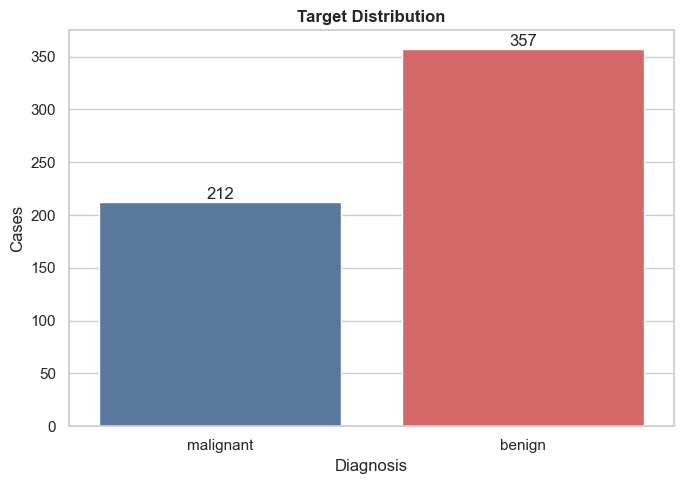

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x='diagnosis_label', palette=['#4C78A8', '#E45756'], ax=ax)
ax.set_title('Target Distribution')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Cases')
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'target_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

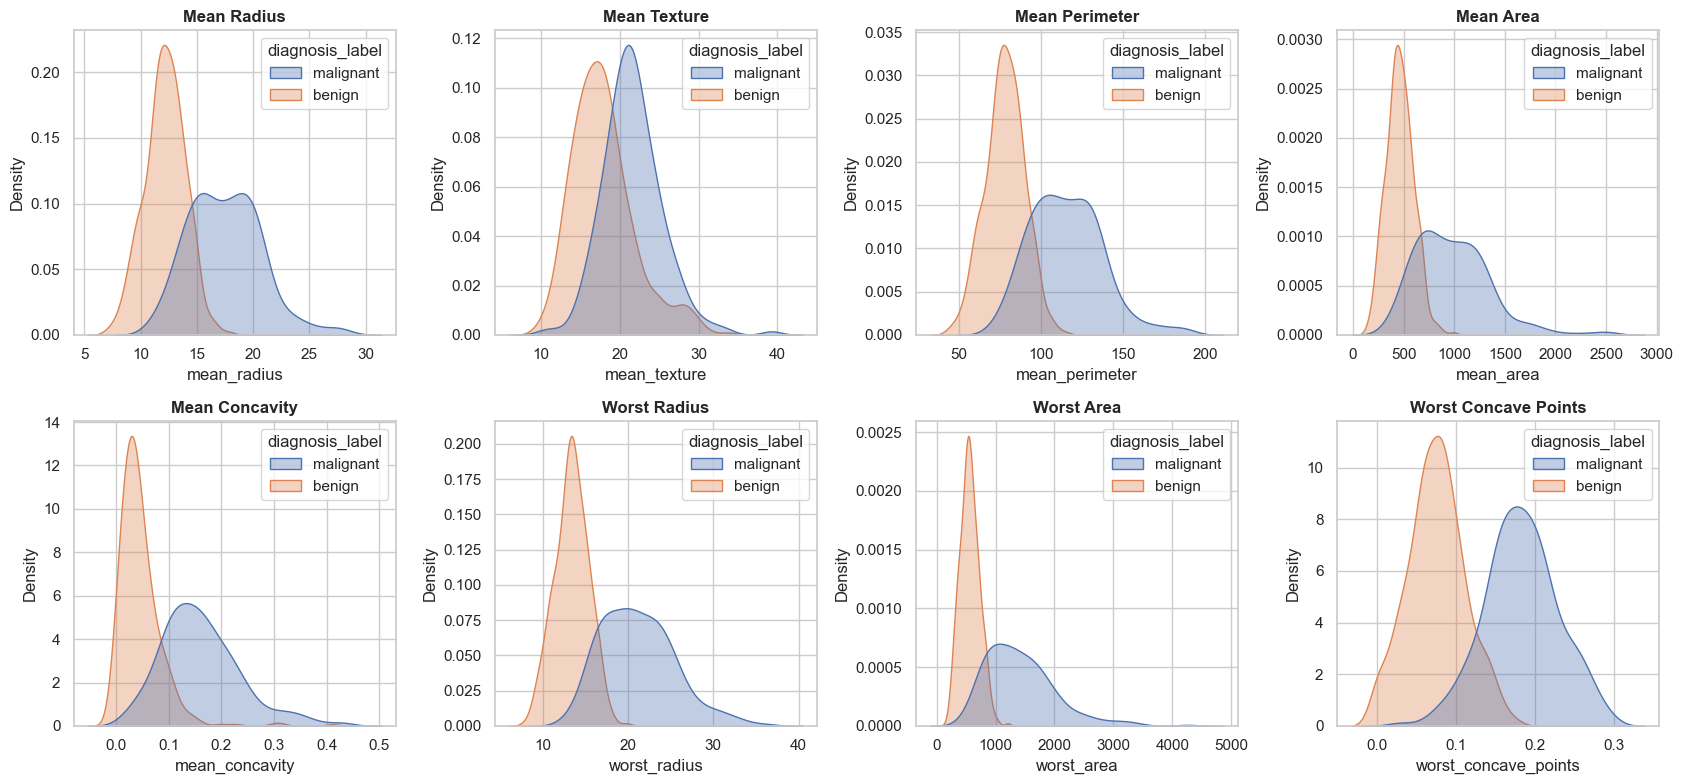

In [5]:
selected = ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_concavity', 'worst_radius', 'worst_area', 'worst_concave_points']
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, col in zip(axes.ravel(), selected):
    sns.kdeplot(data=df, x=col, hue='diagnosis_label', fill=True, common_norm=False, alpha=0.35, ax=ax)
    ax.set_title(col.replace('_', ' ').title())
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'feature_distributions.png', dpi=160, bbox_inches='tight')
plt.show()

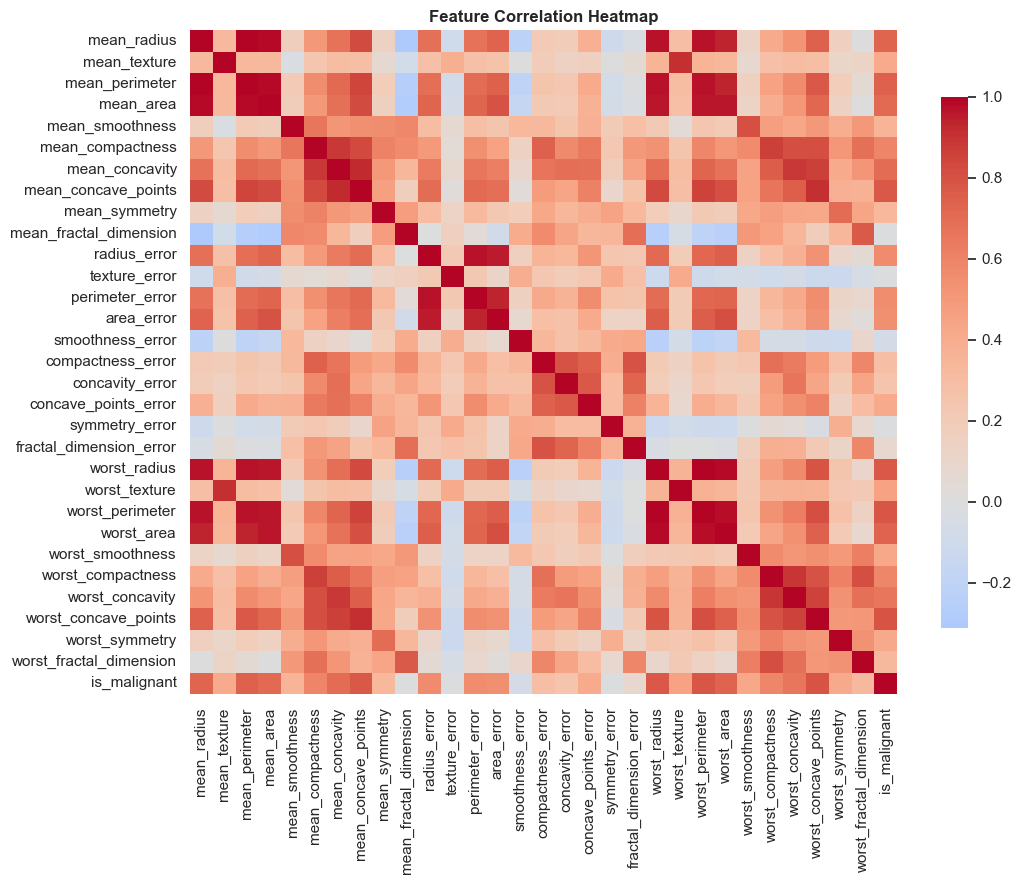

In [6]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = df.drop(columns=['diagnosis_label']).corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'correlation_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()

## 10. Build Predictive Model

We train an XGBoost classifier.

Tree boosting is powerful because it captures nonlinear patterns and feature interactions. But that power comes with opacity. The model can make strong predictions without giving a human-readable reason by default.

That is exactly why SHAP becomes useful.

In [7]:
X_train, X_test, y_train, y_test = split_features_target(df)
model = train_xgboost_classifier(X_train, y_train)
metrics = evaluate_classifier(model, X_train, X_test, y_train, y_test)
display(metrics)

pred = model.predict(X_test)
print(classification_report(y_test, pred, target_names=['benign', 'malignant']))

,split,accuracy,precision,recall,f1,roc_auc
0,train,1.000000,1.0,1.000000,1.000000,1.000000
1,test,0.972028,1.0,0.924528,0.960784,0.997904


              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        90
   malignant       1.00      0.92      0.96        53

    accuracy                           0.97       143
   macro avg       0.98      0.96      0.97       143
weighted avg       0.97      0.97      0.97       143



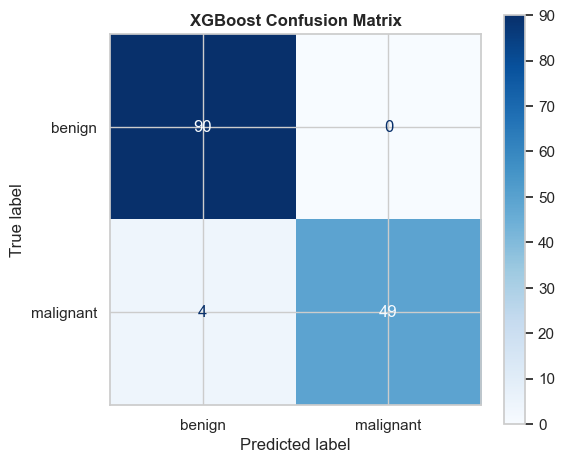

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=['benign', 'malignant'], cmap='Blues', ax=ax)
ax.set_title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'confusion_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

## 11. Traditional Feature Importance

Built-in feature importance is a useful first glance.

But it has a limitation: it is global and blunt. It can tell us which features matter overall, but not why a specific patient was predicted malignant or benign.

This is the transition point from “the model cares about these columns” to “this prediction happened because of these exact pushes.”

,feature,importance
22,worst_perimeter,0.244843
20,worst_radius,0.240815
7,mean_concave_points,0.118103
27,worst_concave_points,0.079500
25,worst_compactness,0.033333
3,mean_area,0.030065
26,worst_concavity,0.028474
1,mean_texture,0.020556
21,worst_texture,0.020209
16,concavity_error,0.017594


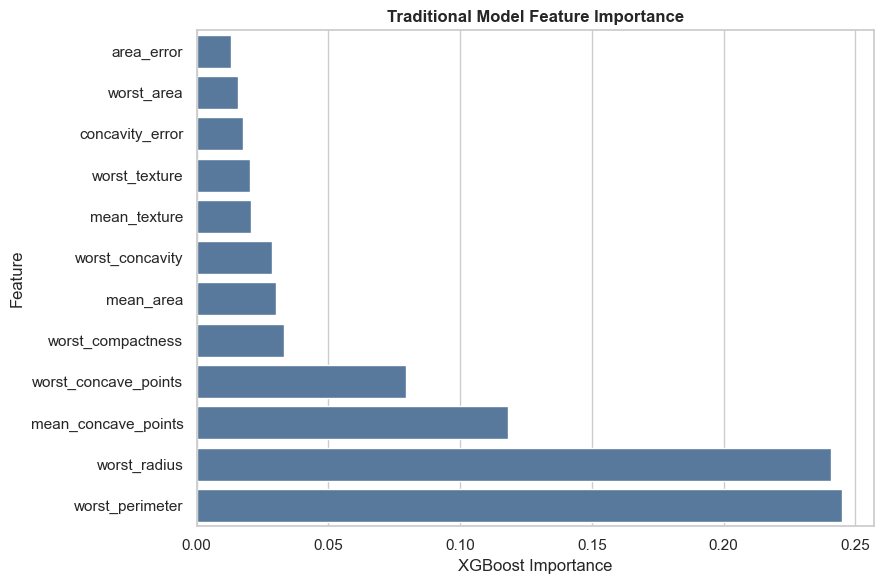

In [9]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
display(feature_importance.head(12))

fig, ax = plt.subplots(figsize=(9, 6))
plot_data = feature_importance.head(12).iloc[::-1]
sns.barplot(data=plot_data, x='importance', y='feature', color='#4C78A8', ax=ax)
ax.set_title('Traditional Model Feature Importance')
ax.set_xlabel('XGBoost Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

## 12. Understanding SHAP Values

SHAP starts with a baseline model output.

Then each feature adds or subtracts from that baseline.

For a malignant prediction:

- positive SHAP values push the model toward malignant
- negative SHAP values push the model away from malignant

This additive structure is what makes SHAP feel like opening the model's ledger.

In [10]:
background = shap.sample(X_train, 120, random_state=42)
explain_X = X_test.copy()
explainer, shap_values = compute_tree_shap(model, explain_X)
print(type(shap_values))
print(shap_values.values.shape)

<class 'shap._explanation.Explanation'>
(143, 30)


## 13. Global Explainability

Global SHAP explanations show what the model tends to rely on across many predictions.

The summary plot shows both importance and direction. A feature can be important because high values push risk up, low values push risk down, or both.

In [11]:
plt.figure()
shap.summary_plot(shap_values, explain_X, show=False, max_display=15)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_summary_plot.png', dpi=180, bbox_inches='tight')
plt.close()

plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('SHAP Global Feature Importance')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_bar_plot.png', dpi=180, bbox_inches='tight')
plt.close()

shap_importance = mean_abs_shap(shap_values, explain_X.columns)
display(shap_importance.head(12))

,feature,mean_abs_shap
7,mean_concave_points,0.692507
27,worst_concave_points,0.673714
21,worst_texture,0.582002
13,area_error,0.574575
26,worst_concavity,0.559874
20,worst_radius,0.467862
22,worst_perimeter,0.407961
23,worst_area,0.372494
1,mean_texture,0.332137
15,compactness_error,0.238271


## 14. Local Explainability

Now the black box becomes personal.

Instead of asking what the model usually cares about, we ask:

> Why did this specific prediction happen?

We pick one high-risk malignant prediction and inspect the feature pushes behind it.

In [12]:
proba = model.predict_proba(explain_X)[:, 1]
local_index = int(np.argmax(proba))
print('Selected test row index:', local_index)
print('Predicted probability of malignant:', round(proba[local_index], 4))
print('Actual label:', 'malignant' if y_test.iloc[local_index] == 1 else 'benign')

local_df = local_contribution_frame(shap_values, explain_X, local_index)
display(local_df.head(12))

Selected test row index: 107
Predicted probability of malignant: 0.9984
Actual label: malignant


,feature,value,shap_value,abs_shap
27,worst_concave_points,0.18720,1.181752,1.181752
13,area_error,69.65000,1.004353,1.004353
7,mean_concave_points,0.09664,0.985264,0.985264
21,worst_texture,35.90000,0.857198,0.857198
20,worst_radius,23.72000,0.805786,0.805786
22,worst_perimeter,159.80000,0.803658,0.803658
26,worst_concavity,0.57540,0.757320,0.757320
23,worst_area,1724.00000,0.658999,0.658999
1,mean_texture,26.60000,0.589170,0.589170
3,mean_area,1138.00000,0.216802,0.216802


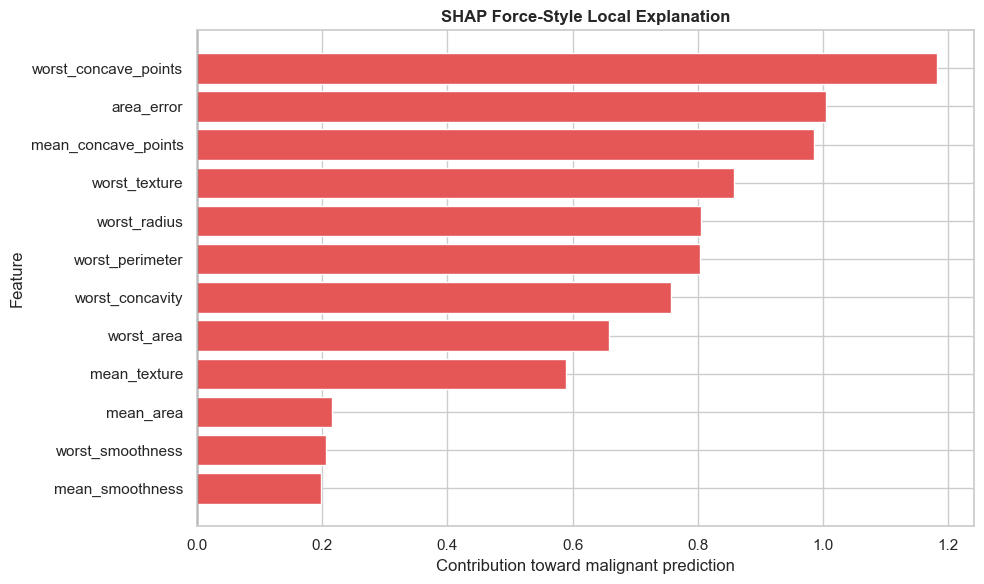

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_local = local_df.head(12).sort_values('shap_value')
colors = ['#E45756' if v > 0 else '#4C78A8' for v in plot_local['shap_value']]
ax.barh(plot_local['feature'], plot_local['shap_value'], color=colors)
ax.axvline(0, color='#333333', linewidth=1)
ax.set_title('SHAP Force-Style Local Explanation')
ax.set_xlabel('Contribution toward malignant prediction')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_force_plot.png', dpi=160, bbox_inches='tight')
plt.show()

In [14]:
plt.figure()
shap.plots.waterfall(shap_values[local_index], max_display=12, show=False)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_waterfall_plot.png', dpi=180, bbox_inches='tight')
plt.close()

## 15. SHAP Dependence Plots

Dependence plots show how one feature's value changes its SHAP contribution.

This is where nonlinear behavior becomes visible. The model may not treat a feature as simply “more is always worse.” It may respond strongly only after a threshold.

In [15]:
top_feature = shap_importance.iloc[0]['feature']
plt.figure()
shap.dependence_plot(top_feature, shap_values.values, explain_X, show=False, interaction_index='auto')
plt.title(f'SHAP Dependence Plot: {top_feature}')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_dependence_plot.png', dpi=180, bbox_inches='tight')
plt.close()
print('Top dependence feature:', top_feature)

Top dependence feature: mean_concave_points


## 16. Explaining Wrong Predictions

Explainability is not only for storytelling. It is a debugging tool.

When a model is wrong, SHAP helps us ask whether the error came from a reasonable ambiguity, a suspicious shortcut, a missing feature, or a pattern we do not trust.

In [16]:
errors = misclassification_frame(model, X_test, y_test)
error_rows = errors[errors['is_error']]
print('Misclassified test cases:', len(error_rows))
display(error_rows[['actual', 'predicted', 'probability_malignant']].head())

if len(error_rows) > 0:
    error_position = explain_X.index.get_loc(error_rows.index[0])
    error_local = local_contribution_frame(shap_values, explain_X, error_position)
    display(error_local.head(10))
else:
    print('No test errors in this split. That is possible on this compact benchmark, but the debugging workflow still applies.')

Misclassified test cases: 4


,actual,predicted,probability_malignant
86,1,0,0.285830
385,1,0,0.322136
205,1,0,0.423854
73,1,0,0.024701


,feature,value,shap_value,abs_shap
13,area_error,38.87000,0.910278,0.910278
7,mean_concave_points,0.04938,-0.661140,0.661140
26,worst_concavity,0.33490,0.591515,0.591515
21,worst_texture,29.25000,0.580569,0.580569
1,mean_texture,21.46000,0.422677,0.422677
15,compactness_error,0.02983,-0.320498,0.320498
4,mean_smoothness,0.09444,0.172019,0.172019
28,worst_symmetry,0.30200,0.156468,0.156468
27,worst_concave_points,0.12250,-0.120078,0.120078
24,worst_smoothness,0.13060,-0.108958,0.108958


## 17. Explainability and Bias Detection

This medical dataset does not include demographic sensitive attributes like race, age, or sex.

That absence is itself an important fairness lesson: you cannot audit every kind of bias if the dataset does not contain the right context.

Still, SHAP can help detect suspicious proxy behavior. If a model depends heavily on features that should not drive a decision, or if explanations differ sharply across subgroups, the team has a reason to investigate.

Explainability does not automatically make a model fair. It makes questions easier to ask.

In [17]:
fairness_proxy = errors.copy()
fairness_proxy['radius_band'] = pd.qcut(fairness_proxy['mean_radius'], q=4, labels=['low', 'medium_low', 'medium_high', 'high'])
subgroup = fairness_proxy.groupby('radius_band').agg(
    rows=('actual', 'size'),
    actual_malignant_rate=('actual', 'mean'),
    predicted_malignant_rate=('predicted', 'mean'),
    error_rate=('is_error', 'mean')
).reset_index()
display(subgroup)

,radius_band,rows,actual_malignant_rate,predicted_malignant_rate,error_rate
0,low,36,0.000000,0.000000,0.000000
1,medium_low,36,0.083333,0.083333,0.000000
2,medium_high,35,0.428571,0.314286,0.114286
3,high,36,0.972222,0.972222,0.000000


## 18. Explainability vs Accuracy Tradeoff

Some models are naturally interpretable. Logistic regression and small decision trees are easier to explain directly.

Other models, like gradient boosting, random forests, and neural networks, can be more accurate but harder to inspect.

The business question is not always “which model has the highest score?”

In healthcare, finance, hiring, and safety-critical systems, the better question may be:

> Which model is accurate enough and explainable enough to trust responsibly?

## 19. Real-World Applications

SHAP and explainability appear wherever model decisions need accountability:

- healthcare diagnosis support
- credit scoring and loan approvals
- insurance risk models
- fraud detection
- hiring systems
- churn prediction
- recommendation systems
- GenAI safety and evaluation

The common theme is trust. If a prediction affects people, someone eventually needs to understand it.

## 20. Limitations of SHAP

SHAP is powerful, but not magic.

Important limitations:

- can be computationally expensive
- explanations can be hard to interpret with correlated features
- local explanations can be over-read as causal stories
- plots require domain knowledge
- explanations can reveal model behavior without proving the model is fair

SHAP explains what the model learned. It does not guarantee the model learned the right thing.

## 21. Final Takeaway

Explainability turns model evaluation from “how well did it score?” into “can we understand and trust how it behaves?”

GraphX Labs takeaway:

> A black-box model may predict. An explainable model can be questioned.

## 22. Interview Questions

A detailed interview guide is available here:

```text
../interview_questions.md
```

Use it to connect SHAP intuition to practical machine learning interviews.